# V1DD 2P Preprocessing (2026 / NWB-Zarr)

Cell-cell correlation preprocessing from the NWB-Zarr functional asset (`409828_V1DD_Filtered`). It produces three derived tables:

| output | contents |
|---|---|
| `cell_cell_correlations_by_stimulus` | pairwise dF/F correlation per cell pair, one column per stimulus |
| `cell_cell_correlations_by_stimulus_coregistered` | the above, restricted to EM-coregistered pairs, keyed by `pt_root_id` |
| `snr_by_cell` | frequency-domain SNR estimate per ROI |

In [1]:
import os
import sys
import platform
import warnings
from os.path import join as pjoin
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow 
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats, interpolate
from IPython.display import display
from tqdm.auto import tqdm

from hdmf_zarr import NWBZarrIO
from pynwb import NWBHDF5IO


def session_io(path):
    """Open a session NWB read-only, in whichever format it was written.

    Most sessions in this asset are NWB-Zarr directories (``*.nwb.zarr``); a few are
    plain HDF5 files (``*.nwb``). Both readers hand back the same ``pynwb.NWBFile``, so
    nothing downstream needs to know which it got.
    """
    path = str(path)
    if path.endswith(".nwb.zarr"):
        return NWBZarrIO(path, mode="r")
    return NWBHDF5IO(path, mode="r")

warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

## Paths and output location

Derived tables are written to **`/scratch`** by default, CodeOcean's ephemeral working space. Flip `OUTPUT_TARGET` to `"results"` to capture under a reproducible run.

In [2]:
mat_version = 1196

# ---- data root: platform switch --------------------------
platstring = platform.platform()
system = platform.system()
if os.environ.get("SWDB_DATA_ROOT"):
    # explicit override -> highest precedence
    data_root = os.environ["SWDB_DATA_ROOT"]
elif system == "Darwin":
    # macOS
    data_root = "/Volumes/Brain2026/"
elif system == "Windows":
    # Windows (replace with the drive letter of USB drive)
    data_root = "E:/"
elif "amzn" in platstring:
    # then on CodeOcean
    data_root = "/data/"
else:
    # then your own linux platform
    # EDIT location where you mounted hard drive
    data_root = "/media/$USERNAME/Brain2026/"

data_dir = pjoin(data_root, f"v1dd_{mat_version}")              # EM-side products
functional_dir = pjoin(data_root, "409828_V1DD_Filtered")       # NWB-Zarr sessions

# ---- save root: where derived tables go --------------------
output_target = "results"   # "scratch" (default, ephemeral) | "results" (reproducible run)
save_root = f"/{output_target}"
save_dir = pjoin(save_root, f"v1dd_{mat_version}_coreg_functional_correlation")
os.makedirs(save_dir, exist_ok=True)

## Coregistration information (EM <-> functional)

The linkage between the Structural data (electron microscopy, EM) and Functional data (2-photon calcium imaging, 2P) exists as a table in the Connectome Annotation Versioning Engine (CAVE). 

Table `functional_coregistration_manual_2` it the **matched indexers** between the EM and 2P functional data. This matching index lives in CAVE because `pt_root_id` changes with time under proofreading. The functional ROI is expected to be static. Query the live matching from CAVE for a unified, timestamped, and versioned source of truth. 

**Initialize CAVEclient and input token.** Querying that datastack requires inputing a user authentication token. Follow prompts below.

In [3]:
from caveclient import CAVEclient

# Initialize CAVEclient
client = CAVEclient("v1dd_public", server_address="https://global.em.brain.allentech.org", 
                    auth_token=os.environ["API_SECRET"], 
                    version=mat_version)

/opt/conda/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.5.1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


Updated datastack-to-server cache — 'https://global.em.brain.allentech.org' will now be used by default for datastack 'v1dd_public'


In [4]:
# Query the coregistration table
coreg_table_name = "functional_coregistration_manual_2"
coreg_keys = ["column", "volume", "plane", "roi","pt_root_id"]

coreg_df = client.materialize.query_table(coreg_table_name)[coreg_keys]

# Data cleaning: remove true-duplicate entries. Duplicates on 'pt_root_id' preserved, see note on the duplication below.
coreg_df = coreg_df.drop_duplicates(subset = ['column', 'volume','plane','roi'], keep='first')

coreg_df

,column,volume,plane,roi,pt_root_id
0,1,3,0,143,864691132830842994
1,1,3,2,40,864691132741466457
2,1,3,3,98,864691132770893729
4,1,3,0,100,864691132999240117
5,1,3,0,60,864691132760377194
...,...,...,...,...,...
566,1,3,2,236,864691132744008540
567,1,3,2,383,864691132810202401
568,1,3,2,393,864691132925592361
569,1,3,0,89,864691132884727983


In [5]:
# summarize the number of coregistered neurons per session, to pick sessions with many simulataneously recorded cells

units_per_session = pd.DataFrame(coreg_df.value_counts(['column', 'volume']))

coregisted_session_by_column_volume = sorted({(int(c), int(v)) for c, v in
                                              zip(coreg_df["column"], coreg_df["volume"])})
print(coregisted_session_by_column_volume)

units_per_session

[(1, 3), (1, 5), (2, 5)]


count
column volume       
1      3         358
       5         123
2      5          84

There are only **3 sessions with coregistered cells**. We will show how to excerpt only these sessions below.

In [6]:
# save to outputs : versioned coregistration information from CAVE

coreg_df.to_feather(pjoin(save_dir, f"coregistration_{mat_version}.feather"), compression="zstd")

### Important data duplication note:

There can be more then 1 recording (unique row) of the same EM cell (unique root id). Most often in different planes of the same session. Be mindful of duplicates when joining tables on `pt_root_id`.

In [7]:
# multiple recordings of the same structural cell
coreg_df.value_counts('pt_root_id').head(20)

pt_root_id
864691132709485099    2
864691132770893729    2
864691132604634905    2
864691132773390355    2
864691132763842142    2
864691132637154545    2
864691133000822453    2
864691132644511162    2
864691132565276366    2
864691132609937787    2
864691132691044586    2
864691132796434159    2
864691132779942048    1
864691132780588911    1
864691132780926923    1
864691132781219967    1
864691132781350783    1
864691132779137802    1
864691132782037514    1
864691132782161650    1
Name: count, dtype: int64

## Session discovery and selection

Every session is uniquely indexed by the combination of its `(column, volume)`. Above we retrieved the identify of sessions with meaningful amount of coregistration.


These are the coregistered sessions:

> **`(column 1, volume 3)`, `(column 1, volume 5)`, `(column 2, volume 5)`**

However, we have many more functional sessions. And one of the coregistered sessions fell out of functional QC. Here we generate a summary of available functional data (this takes 5 minutes to collate).

or you can load from cached results:

```
session_index = pd.read_csv(pjoin(save_dir, "session_index.csv"))
```


In [8]:
%%time
# NWB layout: <asset>/<session_name>/<something>.nwb.zarr, or <something>.nwb
#
# The asset is MIXED FORMAT. Globbing only for *.nwb.zarr does not fail -- it silently
# returns a shorter list, so every downstream statistic is quietly computed on a subset.
# Collect both patterns.
_functional_root = Path(functional_dir)
_zarr = sorted(_functional_root.glob("*/*.nwb.zarr"))
_hdf5 = sorted(_functional_root.glob("*/*.nwb"))
if not _zarr and not _hdf5:
    _zarr = sorted(_functional_root.rglob("*.nwb.zarr"))
    _hdf5 = sorted(_functional_root.rglob("*.nwb"))

# A *.nwb name *inside* a *.nwb.zarr directory belongs to that store; it is not a session.
# (The two glob patterns themselves do not overlap: a Zarr store's name ends in .zarr.)
_hdf5 = [p for p in _hdf5 if not any(part.endswith(".nwb.zarr") for part in p.parts)]

session_paths = sorted(_zarr + _hdf5, key=lambda p: p.parent.name)
if not session_paths:
    raise FileNotFoundError(
        f"No *.nwb.zarr or *.nwb found anywhere under {functional_dir}")


def peek_session(path):
    """Read (column, volume, n_planes) from a session without loading any traces."""
    info = {"path": path, "name": path.parent.name,
            "format": "zarr" if str(path).endswith(".nwb.zarr") else "hdf5",
            "column": np.nan, "volume": np.nan, "n_planes": np.nan, "session_id": ""}
    try:
        with session_io(path) as _io:
            nwb = _io.read()
            planes = [k for k in nwb.processing if k.startswith("plane-")]
            info["n_planes"] = len(planes)
            info["session_id"] = str(nwb.session_id)
            if planes:
                first = sorted(planes, key=lambda k: int(k.split("-", 1)[1]))[0]
                rois = nwb.processing[first]["dff"].rois.to_dataframe()
                info["column"] = int(pd.to_numeric(rois["column"]).iloc[0])
                info["volume"] = int(pd.to_numeric(rois["volume"]).iloc[0])
    except Exception as exc:
        warnings.warn(f"could not index {path.parent.name}: {type(exc).__name__}: {exc}")
    return info


print(f"Indexing {len(session_paths)} session(s) under {functional_dir} "
      f"({len(_zarr)} zarr, {len(_hdf5)} hdf5) ...\n")
session_index = pd.DataFrame([peek_session(p) for p in session_paths])

session_index

Indexing 25 session(s) under /data/409828_V1DD_Filtered (25 zarr, 0 hdf5) ...



CPU times: user 1min 52s, sys: 1.42 s, total: 1min 53s
Wall time: 6min 7s


,path,name,format,column,volume,n_planes,session_id
0,/data/409828_V1DD_Filtered/409828_2018-11-06_1...,409828_2018-11-06_14-02-59_filtered_2026-04-09...,zarr,2,1,6,774328450
1,/data/409828_V1DD_Filtered/409828_2018-11-20_1...,409828_2018-11-20_10-42-45_filtered_2026-04-09...,zarr,3,1,6,783110306
2,/data/409828_V1DD_Filtered/409828_2018-11-20_1...,409828_2018-11-20_12-12-08_filtered_2026-04-09...,zarr,3,2,6,783251261
3,/data/409828_V1DD_Filtered/409828_2018-11-21_0...,409828_2018-11-21_09-22-23_filtered_2026-04-16...,zarr,4,1,6,783878040
4,/data/409828_V1DD_Filtered/409828_2018-11-21_1...,409828_2018-11-21_10-56-07_filtered_2026-04-09...,zarr,4,2,6,784057573
5,/data/409828_V1DD_Filtered/409828_2018-11-26_1...,409828_2018-11-26_11-16-25_filtered_2026-04-09...,zarr,5,1,6,785378984
6,/data/409828_V1DD_Filtered/409828_2018-11-27_1...,409828_2018-11-27_11-01-58_filtered_2026-04-09...,zarr,2,2,6,785941763
7,/data/409828_V1DD_Filtered/409828_2018-11-27_1...,409828_2018-11-27_12-29-05_filtered_2026-04-09...,zarr,2,3,6,786071018
8,/data/409828_V1DD_Filtered/409828_2018-11-28_1...,409828_2018-11-28_10-54-56_filtered_2026-04-16...,zarr,3,3,6,786879416
9,/data/409828_V1DD_Filtered/409828_2018-11-29_1...,409828_2018-11-29_13-42-04_filtered_2026-04-09...,zarr,5,2,6,788220278


In [9]:
# Add coregistration information:

session_index["coregistered"] = [
    (c, v) in coregisted_session_by_column_volume
    for c, v in zip(session_index["column"], session_index["volume"])
]

In [10]:
# save to outputs : session index with unique identifiers and coregistration status

session_index.to_csv(pjoin(save_dir, "session_index.csv"), index=False,)     # save to .csv for easy external use

## Helper functions

### load and integration 

Three functions load and annotate the relevant functional data. Each takes the NWB file (or already-loaded arrays)

In [11]:
def load_session_dff(nwbfile, trace_type="dff", reference_plane=None,
                     require_soma=False, method="interp1d", dtype=np.float32):
    """Concatenate every imaging plane onto a single reference timebase.

    NWB-Zarr stores traces as ``(n_frames, n_rois)``. 
    We interpolate along **axis=0** (time) and transpose exactly once, on return, 
    so that every downstream consumer -- ``np.corrcoef``, the FFT SNR
    estimator -- sees ``(n_rois, n_time)`` . 

    Planes are whatever ``processing['plane-*']`` modules exist. 

    Parameters
    ----------
    trace_type : {"dff", "events", ...}
        Which data interface to pull from each plane module.
    reference_plane : str, int or None
        Plane whose timestamps define the common timebase. Defaults to the lowest plane.
    require_soma : bool
        Keep only ROIs flagged ``is_soma`` in the plane's roi table.
    method : {"interp1d", "np"}
        ``interp1d`` extrapolates past each plane's timestamp range. 
        ``np`` uses ``np.interp``, which clamps at the edges instead.

    Returns
    -------
    dict with keys: dff, roi_table, plane, roi, base_time, dt, fs
    """
    keys = sorted((k for k in nwbfile.processing if k.startswith("plane-")),
                  key=lambda k: int(k.split("-", 1)[1]))
    if not keys:
        raise KeyError("no 'plane-*' processing modules in this NWB file")

    if reference_plane is None:
        reference_plane = keys[0]
    elif isinstance(reference_plane, (int, np.integer)):
        reference_plane = f"plane-{int(reference_plane)}"

    base_times = np.asarray(
        nwbfile.processing[reference_plane][trace_type].timestamps[:], dtype=np.float64
    )

    traces, roi_tables = [], []
    for key in keys:
        module = nwbfile.processing[key]
        if trace_type not in module.data_interfaces:
            warnings.warn(f"{key}: no '{trace_type}' interface; skipping this plane")
            continue
        series = module[trace_type]

        t = np.asarray(series.timestamps[:], dtype=np.float64)
        data = np.asarray(series.data[:], dtype=np.float64)   # expected (n_frames, n_rois)

        # Orientation guard: fail loudly rather than silently transposing the wrong way.
        if data.shape[0] != t.shape[0]:
            if data.ndim == 2 and data.shape[1] == t.shape[0]:
                warnings.warn(f"{key}/{trace_type}: stored (n_rois, n_frames); transposing")
                data = data.T
            else:
                raise ValueError(
                    f"{key}: data {data.shape} incompatible with timestamps {t.shape}"
                )

        roi_df = series.rois.to_dataframe().reset_index(drop=False)
        roi_df = roi_df.rename(columns={"id": "nwb_roi_row_id"})
        # pixel_mask is ragged and large; drop it here
        roi_df = roi_df.drop(columns=[c for c in ("pixel_mask",) if c in roi_df.columns])
        if len(roi_df) != data.shape[1]:
            raise ValueError(
                f"{key}: {len(roi_df)} roi rows vs {data.shape[1]} trace columns"
            )

        # The rois table carries its own 'plane'; make sure it agrees with the module name.
        if "plane" in roi_df.columns:
            _p = pd.to_numeric(roi_df["plane"], errors="coerce").dropna().unique()
            if len(_p) == 1 and int(_p[0]) != int(key.split("-", 1)[1]):
                warnings.warn(
                    f"{key}: rois table reports plane={int(_p[0])}. Joins use the table "
                    "value, since that is what the coregistration table keys on."
                )

        keep = np.ones(data.shape[1], dtype=bool)
        if require_soma and "is_soma" in roi_df.columns:
            keep = roi_df["is_soma"].to_numpy().astype(bool)
        data = data[:, keep]
        roi_df = roi_df[keep].reset_index(drop=True)

        if method == "interp1d":
            f_interp = interpolate.interp1d(
                t, data, kind="linear", axis=0, bounds_error=False,
                fill_value="extrapolate",
            )
            resampled = f_interp(base_times)
        elif method == "np":
            resampled = np.empty((base_times.size, data.shape[1]), dtype=np.float64)
            for j in range(data.shape[1]):
                resampled[:, j] = np.interp(base_times, t, data[:, j])
        else:
            raise ValueError("method must be 'interp1d' or 'np'")

        traces.append(resampled.astype(dtype))          # (n_base, n_rois_in_plane)
        roi_df["plane_key"] = key
        roi_tables.append(roi_df)
        del data, resampled

    if not traces:
        raise RuntimeError(f"no plane yielded '{trace_type}' traces")

    dff = np.concatenate(traces, axis=1).T              # <-- the one and only transpose
    roi_table = pd.concat(roi_tables, ignore_index=True)

    for col in ("column", "volume", "plane", "roi"):
        if col in roi_table.columns:
            roi_table[col] = pd.to_numeric(roi_table[col], errors="raise").astype(int)

    dt = float(np.median(np.diff(base_times)))
    return {
        "dff": dff,                # (n_rois_total, n_time)
        "roi_table": roi_table,
        "plane": roi_table["plane"].to_numpy(dtype=int),
        "roi": roi_table["roi"].to_numpy(dtype=int),
        "base_time": base_times,
        "dt": dt,
        "fs": 1.0 / dt,
    }

In [12]:
def get_epoch_table(nwbfile):
    """Stimulus epochs as a tidy frame, sorted by start time."""
    ep = nwbfile.intervals["epochs"].to_dataframe().reset_index(drop=False)
    if "duration" not in ep.columns:
        ep["duration"] = ep["stop_time"] - ep["start_time"]
    return ep.sort_values("start_time").reset_index(drop=True)


def get_combined_stimulus_map(nwbfile, base_times, epoch_table=None, drop=()):
    """Integer stimulus code per imaging frame. 0 means "no retained epoch".

    Stimuli appearing in more than one epoch (e.g. natural_movie at epochs 5 and 10) share
    a single code, which unions their blocks.

    Parameters
    ----------
    drop : iterable of str
        Stimulus names to exclude. Empty by default, so ``spontaneous`` is KEPT (it is a
        legitimate 300 s baseline block).
    """
    if epoch_table is None:
        epoch_table = get_epoch_table(nwbfile)

    drop = set(drop or ())
    names = [n for n in epoch_table["stim_name"].unique() if n not in drop]
    stim_map = {i + 1: n for i, n in enumerate(names)}
    code_of = {n: i for i, n in stim_map.items()}

    stim_mask = np.zeros(len(base_times), dtype=np.int16)
    for row in epoch_table.itertuples(index=False):
        stim_code = code_of.get(row.stim_name)
        if stim_code is None:
            continue
        stim_mask[(base_times >= row.start_time) & (base_times <= row.stop_time)] = stim_code

    return stim_map, stim_mask

### SNR estimation (quality metric)

In [13]:
def estimate_snr_white_noise_model(data, fs, signal_band=(0.1, 1.5),
                                   noise_band=(2.0, 2.1), demean=True,
                                   power_dtype=np.float32):
    """Estimate per-cell SNR from signal-band power against a white-noise reference band.

    Parameters
    ----------
    data : ndarray, shape ``(n_cells, n_timepoints)``
        Note the orientation. NWB-Zarr gives ``(n_frames, n_rois)``; ``load_session_dff``
        has already transposed, so the FFT stays on ``axis=1``
    fs : float
        Sampling rate in Hz. Recommended to derive it from the timestamps (``session_data["fs"]``).
    signal_band, noise_band : (float, float)
        Frequency bands in Hz. Noise power per bin is scaled up to the signal band's width.

    Returns
    -------
    snr, freqs, power_spectrum, signal_power, noise_power_scaled
    """
    data = np.asarray(data, dtype=np.float64)
    if data.ndim != 2:
        raise ValueError(f"expected 2-D (n_cells, n_time), got shape {data.shape}")
    n_cells, n_timepoints = data.shape
    if demean:
        data = data - data.mean(axis=1, keepdims=True)   # kill the DC bin

    freqs = np.fft.rfftfreq(n_timepoints, d=1.0 / fs)
    nyquist = freqs[-1]
    if noise_band[1] > nyquist:
        raise ValueError(
            f"noise_band {noise_band} exceeds Nyquist {nyquist:.3f} Hz at fs={fs:.3f} Hz. "
            "Choose a noise band below Nyquist."
        )

    power_spectrum = (np.abs(np.fft.rfft(data, axis=1)) ** 2).astype(power_dtype)

    signal_mask = (freqs >= signal_band[0]) & (freqs <= signal_band[1])
    noise_mask = (freqs >= noise_band[0]) & (freqs <= noise_band[1])
    if signal_mask.sum() == 0 or noise_mask.sum() == 0:
        raise ValueError(
            f"empty frequency band: signal={signal_mask.sum()} noise={noise_mask.sum()} bins"
        )

    signal_power = power_spectrum[:, signal_mask].sum(axis=1, dtype=np.float64)
    noise_per_bin = power_spectrum[:, noise_mask].mean(axis=1, dtype=np.float64)
    noise_power_scaled = noise_per_bin * signal_mask.sum()   # scale to signal band width

    snr = signal_power / (noise_power_scaled + 1e-12)

    return snr, freqs, power_spectrum, signal_power, noise_power_scaled

## Example: single-session load

For initial correlation analysis, we pick `(column 1, volume 3)`.

Alternately, consider `(column 1, volume 5)` which we know to have the most coregistered cells. More cells are more interprettable for single-session results. Fewer cells are easier for iterating analysis.


In [14]:
# load session_index to save rederiving it (5 min)
session_index = pd.read_csv(pjoin(save_dir, "session_index.csv"))

session_path = session_index.query("(column == 1) & (volume == 3)").path.item()
print(session_path)

/data/409828_V1DD_Filtered/409828_2018-12-13_15-10-05_filtered_2026-04-09_05-57-20/409828_2018-12-13_15-10-05.nwb.zarr


In [15]:
io = session_io(session_path)
nwbfile_zarr = io.read()

plane_keys = sorted(
    (k for k in nwbfile_zarr.processing if k.startswith("plane-")),
    key=lambda k: int(k.split("-", 1)[1]),
)
mouse_id = int(nwbfile_zarr.subject.subject_id)
session_id = str(nwbfile_zarr.session_id)

print(f"session_id      : {session_id}")
print(f"subject         : {mouse_id}  ({nwbfile_zarr.subject.genotype})")
print(f"description     : {nwbfile_zarr.experiment_description}")
print(f"imaging planes  : {plane_keys}")
print(f"processing keys : {sorted(nwbfile_zarr.processing.keys())}")
print(f"interval tables : {sorted(nwbfile_zarr.intervals.keys())}")
for k in plane_keys:
    print(f"    {k}: {sorted(nwbfile_zarr.processing[k].data_interfaces.keys())}")

session_id      : 794964451
subject         : 409828  (Slc17a7-IRES2-Cre;Camk2a-tTA;Ai94)
description     : 2-photon imaging of column 1, volume 3
imaging planes  : ['plane-0', 'plane-1', 'plane-2', 'plane-3', 'plane-4', 'plane-5']
processing keys : ['behavior', 'plane-0', 'plane-1', 'plane-2', 'plane-3', 'plane-4', 'plane-5']
interval tables : ['epochs', 'stimulus_table']
    plane-0: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
    plane-1: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
    plane-2: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
    plane-3: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
    plane-4: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluore

### Load the session onto a common timebase

Each imaging plane in a volume is acquired at a slightly different time. Every
plane is linearly interpolated onto the reference plane's timestamps so that all cells share
one time axis and can be correlated frame-by-frame.

In [16]:
%%time
session_data = load_session_dff(nwbfile_zarr, trace_type="dff")
epoch_table = get_epoch_table(nwbfile_zarr)
stim_map, stim_mask = get_combined_stimulus_map(
    nwbfile_zarr, session_data["base_time"], epoch_table=epoch_table
)

# column/volume come from the file's own roi table -- never from the directory name.
column = int(session_data["roi_table"]["column"].iloc[0])
volume = int(session_data["roi_table"]["volume"].iloc[0])

n_rois, n_time = session_data["dff"].shape
print(f"session {session_id}:  column {column}, volume {volume}")
print(f"dff: {n_rois} ROIs x {n_time} frames    (n_rois, n_time)")
print(f"fs = {session_data['fs']:.4f} Hz  (dt = {session_data['dt'] * 1e3:.2f} ms), "
      f"span {session_data['base_time'][-1] - session_data['base_time'][0]:.1f} s")
print("\nROIs per plane:")
print(session_data["roi_table"].groupby("plane").size().to_string())

display(epoch_table)

print("frames per stimulus:")
for stim_code, name in stim_map.items():
    n = int((stim_mask == stim_code).sum())
    print(f"  {stim_code:2d}  {name:<30s} {n:6d} frames  ({n * session_data['dt']:7.1f} s)")
print(f"   0  {'<unassigned>':<30s} {int((stim_mask == 0).sum()):6d} frames")

session 794964451:  column 1, volume 3
dff: 2708 ROIs x 21616 frames    (n_rois, n_time)
fs = 6.0591 Hz  (dt = 165.04 ms), span 3570.5 s

ROIs per plane:
plane
0    409
1    470
2    483
3    478
4    438
5    430


,id,stim_name,start_time,stop_time,duration
0,0,drifting_gratings_full,54.634430,341.856873,287.222443
1,1,drifting_gratings_windowed,344.876038,632.098572,287.222534
2,2,locally_sparse_noise,635.117737,875.334412,240.216675
3,3,spontaneous,876.318604,1176.552002,300.233398
4,4,natural_images_12,1179.571167,1331.681152,152.109985
5,5,natural_movie,1343.707764,1794.066162,450.358398
6,6,locally_sparse_noise,1798.119507,2098.236084,300.116577
7,7,natural_images,2100.337891,2399.503662,299.165771
8,8,drifting_gratings_windowed,2414.599609,2701.822021,287.222412
9,9,drifting_gratings_full,2704.841309,2992.063721,287.222412


frames per stimulus:
   1  drifting_gratings_full           3477 frames  (  573.8 s)
   2  drifting_gratings_windowed       3479 frames  (  574.2 s)
   3  locally_sparse_noise             3270 frames  (  539.7 s)
   4  spontaneous                      1820 frames  (  300.4 s)
   5  natural_images_12                 922 frames  (  152.2 s)
   6  natural_movie                    5992 frames  (  988.9 s)
   7  natural_images                   1810 frames  (  298.7 s)
   0  <unassigned>                      846 frames
CPU times: user 1.59 s, sys: 1.53 s, total: 3.11 s
Wall time: 57.8 s


### Sanity check: plot response trace across stimulus epochs

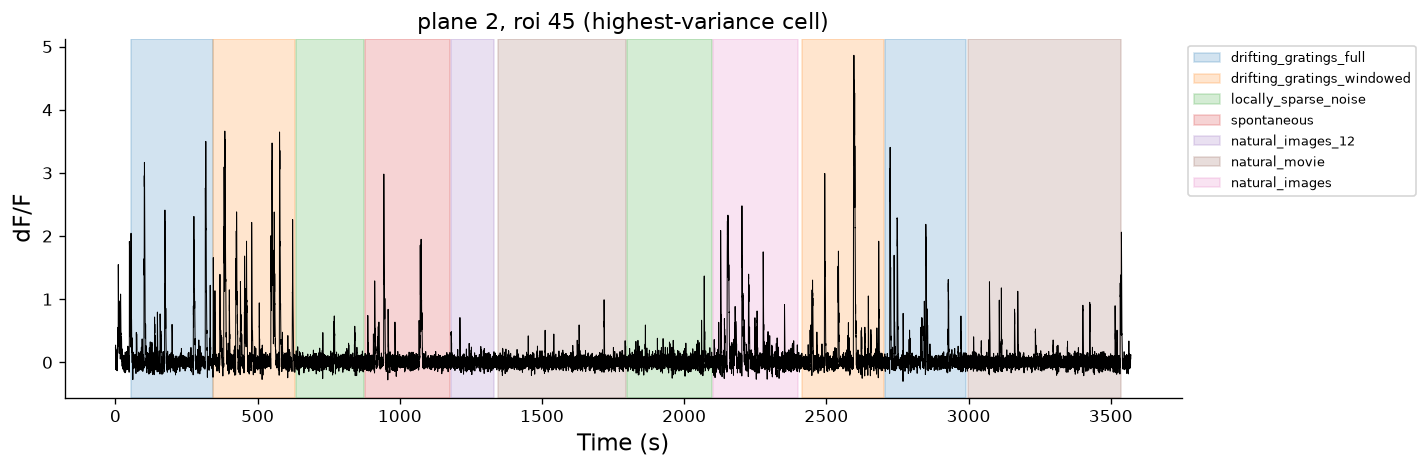

In [17]:
# Figure 1: Sanity check the highest-variance cell, with stimulus epochs shaded.
fig, ax = plt.subplots(figsize=(12, 4), dpi=120)

probe = int(np.argmax(session_data["dff"].std(axis=1)))
ax.plot(session_data["base_time"], session_data["dff"][probe], color="k", lw=0.6)

palette = dict(zip(epoch_table["stim_name"].unique(),
                   sns.color_palette("tab10", epoch_table["stim_name"].nunique())))
seen = set()
for _, row in epoch_table.iterrows():
    label = row["stim_name"] if row["stim_name"] not in seen else None
    seen.add(row["stim_name"])
    ax.axvspan(row["start_time"], row["stop_time"], color=palette[row["stim_name"]],
               alpha=0.20, zorder=0, label=label)

ax.set_xlabel("Time (s)", fontsize=14)
ax.set_ylabel("dF/F", fontsize=14)
ax.set_title(f"plane {session_data['plane'][probe]}, roi {session_data['roi'][probe]} "
             "(highest-variance cell)", fontsize=13)
ax.legend(bbox_to_anchor=(1.0, 1.0), fontsize=8)
sns.despine()
fig.tight_layout()
plt.show()

## Pairwise trace correlations by stimulus

One row per cell pair, one column per stimulus.

Important note: Pairs are extracted with `np.triu_indices(n, k=1)` , more efficient across the matrix.

However, while correlation is symmetric the **connectivity is not symmetric**. It is directional. Storing only one
triangle would silently fail to match half of all connection when joining to synapse tables on `(pre_pt_root_id, post_pt_root_id)`

The structure of the returned output is controlled by `use_symmetric_pairs` which mirrors each pair into both directions. Set it to `False` to halve
memory when you are doing undirected analysis.

In [18]:
use_symmetric_pairs = True   # emit both (i,j) and (j,i); see the note above

def session_correlation_table(session_data, stim_map, stim_mask, column, volume,
                              min_frames=60, symmetric=True, dtype=np.float32):
    """Pairwise dF/F correlations, one column per stimulus.

    Returns ``(corr_df, stim_columns)``. 
            ``stim_columns`` is the authoritative list of stimulus columns
    """
    dff = session_data["dff"]                       # (n_rois, n_time)
    n_rois = dff.shape[0]

    iu, ju = np.triu_indices(n_rois, k=1)
    if symmetric:
        i_idx = np.concatenate([iu, ju])
        j_idx = np.concatenate([ju, iu])
    else:
        i_idx, j_idx = iu, ju
    print(f"{n_rois} ROIs -> {iu.size:,} unordered pairs "
          f"-> {i_idx.size:,} rows (symmetric={symmetric})")

    out = {
        "column": np.full(i_idx.size, column, dtype=np.int16),
        "volume": np.full(i_idx.size, volume, dtype=np.int16),
        "pre_plane": session_data["plane"][i_idx].astype(np.int16),
        "pre_roi": session_data["roi"][i_idx].astype(np.int32),
        "post_plane": session_data["plane"][j_idx].astype(np.int16),
        "post_roi": session_data["roi"][j_idx].astype(np.int32),
    }
    reserved = set(out)

    stim_columns = []
    for stim_code, name in stim_map.items():
        m = stim_mask == stim_code
        n = int(m.sum())
        if n < min_frames:
            print(f"  skipping {name}: {n} frames < min_frames={min_frames}")
            continue
        with np.errstate(invalid="ignore", divide="ignore"):
            corr = np.corrcoef(dff[:, m])           # needs (n_vars, n_obs) -- hence the .T
        col = name if name not in reserved else f"{name}_stim"
        out[col] = corr[i_idx, j_idx].astype(dtype)
        stim_columns.append(col)
        n_nan = int(np.isnan(out[col]).sum())
        print(f"  {name:<30s} {n:6d} frames"
              + (f"   ({n_nan:,} NaN pairs from constant traces)" if n_nan else ""))
        del corr

    return pd.DataFrame(out), stim_columns

### Single-session example

In [19]:
corr_df, stim_columns = session_correlation_table(
    session_data, stim_map, stim_mask, column, volume, symmetric=use_symmetric_pairs
)
print(f"\ncorr_df: {corr_df.shape}  "
      f"({corr_df.memory_usage(deep=True).sum() / 1e6:.0f} MB)")
print(f"stim_columns: {stim_columns}")
corr_df.head()

2708 ROIs -> 3,665,278 unordered pairs -> 7,330,556 rows (symmetric=True)


  drifting_gratings_full           3477 frames


  drifting_gratings_windowed       3479 frames


  locally_sparse_noise             3270 frames


  spontaneous                      1820 frames


  natural_images_12                 922 frames


  natural_movie                    5992 frames


  natural_images                   1810 frames

corr_df: (7330556, 13)  (323 MB)
stim_columns: ['drifting_gratings_full', 'drifting_gratings_windowed', 'locally_sparse_noise', 'spontaneous', 'natural_images_12', 'natural_movie', 'natural_images']


,column,volume,pre_plane,pre_roi,post_plane,post_roi,drifting_gratings_full,drifting_gratings_windowed,locally_sparse_noise,spontaneous,natural_images_12,natural_movie,natural_images
0,1,3,0,0,0,1,0.109838,0.064885,0.163459,0.034445,0.051569,0.713072,0.147359
1,1,3,0,0,0,2,0.037336,0.018882,0.118983,-0.012860,0.043196,-0.016212,0.121114
2,1,3,0,0,0,3,0.105222,0.040017,0.143078,0.018119,0.001986,0.031184,0.174046
3,1,3,0,0,0,4,0.110601,0.116608,0.144799,0.085105,0.156260,0.016074,0.176239
4,1,3,0,0,0,5,0.026775,0.067496,0.041084,0.075696,0.041494,-0.081003,0.131254


### Multi-session aggregation

In [20]:
# load session_index to save rederiving it (5 min)
session_index = pd.read_csv(pjoin(save_dir, "session_index.csv"))
coreg_session_index = session_index.query("coregistered")

coreg_session_index

,path,name,format,column,volume,n_planes,session_id,coregistered
14,/data/409828_V1DD_Filtered/409828_2018-12-07_1...,409828_2018-12-07_15-05-38_filtered_2026-08-18...,zarr,2,5,6,791865124,True
22,/data/409828_V1DD_Filtered/409828_2018-12-13_1...,409828_2018-12-13_15-10-05_filtered_2026-04-09...,zarr,1,3,6,794964451,True
24,/data/409828_V1DD_Filtered/409828_2018-12-14_1...,409828_2018-12-14_14-47-35_filtered_2026-04-09...,zarr,1,5,6,795771997,True


In [21]:
use_symmetric_pairs = True   # emit both (i,j) and (j,i); see the note above

corr_frames, per_session_stims = [], []
for sp in tqdm(coreg_session_index["path"], desc="sessions"):
    with session_io(sp) as _io:
        _nwb = _io.read()
        _sd = load_session_dff(_nwb, trace_type="dff")
        _et = get_epoch_table(_nwb)
        _map, _mask = get_combined_stimulus_map(_nwb, _sd["base_time"], epoch_table=_et)
        _col = int(_sd["roi_table"]["column"].iloc[0])
        _vol = int(_sd["roi_table"]["volume"].iloc[0])
        _df, _stims = session_correlation_table(
            _sd, _map, _mask, _col, _vol, symmetric=use_symmetric_pairs
        )
    corr_frames.append(_df)
    per_session_stims.append(set(_stims))
    del _sd, _df

stim_columns = sorted(set.intersection(*per_session_stims))
_keep = ["column", "volume", "pre_plane", "pre_roi", "post_plane", "post_roi"] + stim_columns
corr_df = pd.concat([f[_keep] for f in corr_frames], ignore_index=True)
del corr_frames

sessions:   0%|          | 0/3 [00:00<?, ?it/s]

906 ROIs -> 409,965 unordered pairs -> 819,930 rows (symmetric=True)
  drifting_gratings_full           3406 frames


  drifting_gratings_windowed       3397 frames


  locally_sparse_noise             3201 frames
  spontaneous                      1785 frames


  natural_images_12                 906 frames


...

  drifting_gratings_windowed       3477 frames
  locally_sparse_noise             3270 frames


  spontaneous                      1820 frames


  natural_images_12                 922 frames


  natural_movie                    6014 frames


  natural_images                   1809 frames


In [22]:
corr_df.tail()

,column,volume,pre_plane,pre_roi,post_plane,post_roi,drifting_gratings_full,drifting_gratings_windowed,locally_sparse_noise,natural_images,natural_images_12,natural_movie,spontaneous
9080741,1,5,5,263,5,207,0.224541,0.043142,0.039513,-0.000663,0.010378,0.062348,0.044739
9080742,1,5,5,270,5,207,0.180876,0.059567,0.038718,0.058787,-0.005293,0.029858,0.039182
9080743,1,5,5,263,5,217,0.242330,0.071736,0.056685,0.068238,0.004950,0.057786,0.051232
9080744,1,5,5,270,5,217,0.147505,0.071827,0.050458,0.085364,0.023485,0.020431,0.036019
9080745,1,5,5,270,5,263,0.209298,0.056292,0.015742,0.047909,0.036972,0.025599,0.075290


In [23]:
# save output: cell-cell correlations under different stimulus regimes, from only the sessions with coregistered cells

corr_df.to_feather(pjoin(save_dir, "cell_cell_correlations_by_stimulus.feather"), compression="zstd")

### Sanity Check: How similar are the correlation structures across stimuli?

Correlate the cell-pair correlation vectors against each other, stimulus by stimulus.

In [24]:
# pearsonr over millions of rows x 49 stimulus combinations is slow; subsample first.
subsample_spacing = max(1, len(corr_df) // 1_000_000)
_sub = corr_df.iloc[::subsample_spacing]
print(f"using every {subsample_spacing}th pair ({len(_sub):,} rows)")

rows = []
for stim_a in stim_columns:
    xa = _sub[stim_a].to_numpy()
    for stim_b in stim_columns:
        xb = _sub[stim_b].to_numpy()
        good = np.isfinite(xa) & np.isfinite(xb)
        r = stats.pearsonr(xa[good], xb[good])[0] if good.sum() > 2 else np.nan
        rows.append({"A": stim_a, "B": stim_b, "corr": r})

stim_stim_corr_df = pd.DataFrame(rows)
stim_stim_corr_df.pivot(index="A", columns="B", values="corr")

using every 9th pair (1,008,972 rows)


B,drifting_gratings_full,drifting_gratings_windowed,locally_sparse_noise,natural_images,natural_images_12,natural_movie,spontaneous
A,,,,,,,
drifting_gratings_full,0.999999,0.437448,0.413734,0.391801,0.256135,0.328357,0.281397
drifting_gratings_windowed,0.437448,0.999999,0.316668,0.338993,0.233656,0.337206,0.260784
locally_sparse_noise,0.413734,0.316668,1.000000,0.519105,0.289926,0.379490,0.294625
natural_images,0.391801,0.338993,0.519105,0.999999,0.292832,0.321729,0.251616
natural_images_12,0.256135,0.233656,0.289926,0.292832,0.999999,0.238391,0.201592
natural_movie,0.328357,0.337206,0.379490,0.321729,0.238391,0.999998,0.266943
spontaneous,0.281397,0.260784,0.294625,0.251616,0.201592,0.266943,0.999998


1,412,565 sampled pair-stimulus observations


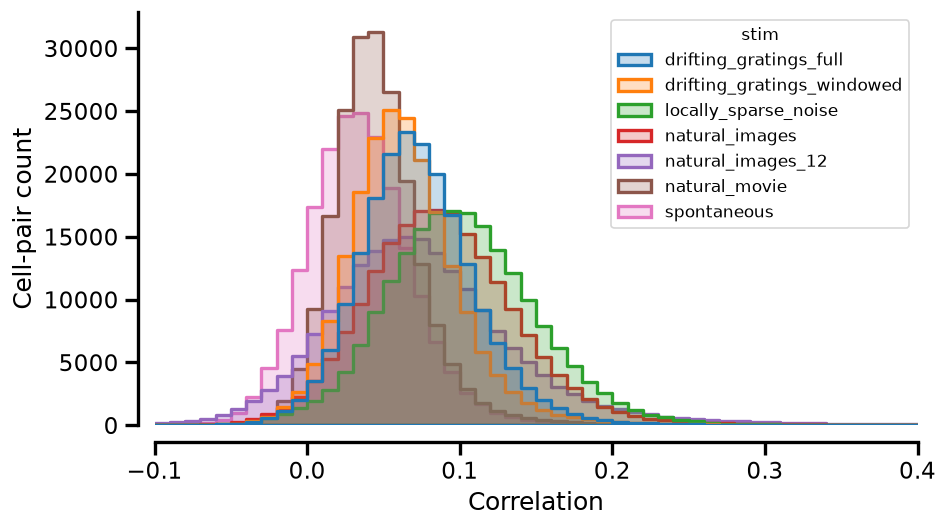

In [25]:
# Figure 2: Do different stimulus conditions exhibit different levels of correlation?

_step = max(1, len(corr_df) // 200_000)
long_df = (corr_df.iloc[::_step]
           .melt(value_vars=stim_columns, var_name="stim", value_name="corr_r")
           .dropna(subset=["corr_r"]))
print(f"{len(long_df):,} sampled pair-stimulus observations")

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
sns.histplot(data=long_df, x="corr_r", hue="stim", bins=np.linspace(-1, 1, 201),
             element="step", lw=2, ax=ax)

ax.tick_params(axis="both", which="major", labelsize=14, width=2, length=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.set_xlim(-0.1, 0.4)
ax.set_xlabel("Correlation", fontsize=15)
ax.set_ylabel("Cell-pair count", fontsize=15)

sns.despine(offset=10, trim=False)
plt.tight_layout()
plt.show()

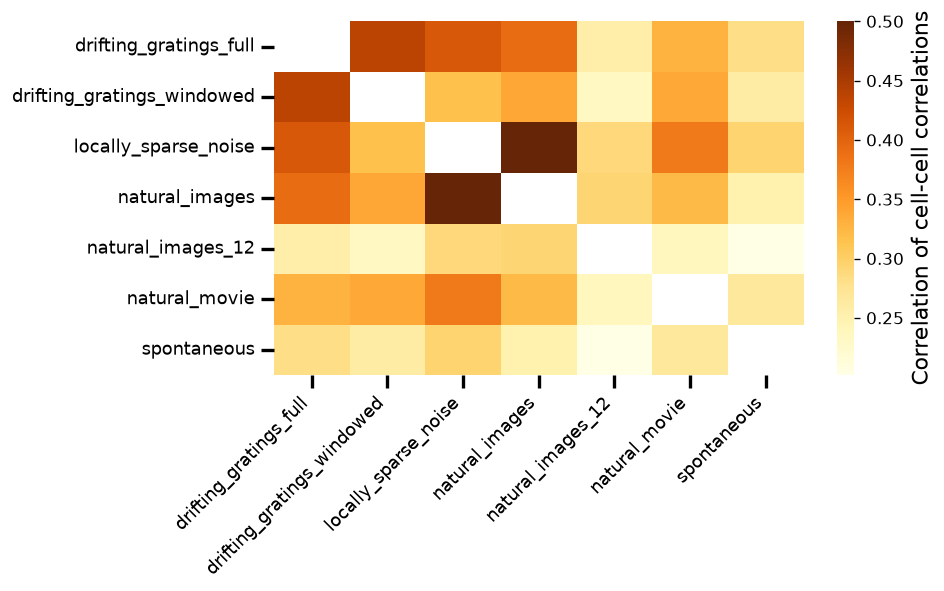

In [26]:
# Figure 3: Are stimulus-specific cell-cell-correlations the same across different stimulus conditions?
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

pivot = (stim_stim_corr_df.pivot(index="A", columns="B", values="corr")
         .loc[stim_columns, stim_columns]
       )

# Fill the diagonal with nan for the self-correlation
np.fill_diagonal(pivot.values, np.nan)

heatmap = sns.heatmap(pivot, ax=ax, vmax=0.5, cmap="YlOrBr")
heatmap.collections[0].colorbar.set_label("Correlation of cell-cell correlations", fontsize=13)

ax.tick_params(axis="both", which="major", labelsize=11, width=2, length=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Attach EM root ids

Match counts are printed at every stage. For an expected-coregistered session the ROI-level
count should be **non-zero**. There may be **more than one** roi recording for EM cell indexed on `pt_root_id`

Unique rois are indexed by the combination of: `column`, `volume`, `plane` AND `roi`.

In [27]:
# load the pre-aggregated coreg_df (saves a CAVEquery)

coreg_df = pd.read_feather(pjoin(save_dir, f"coregistration_{mat_version}.feather"))

# For convenience we are dropping any EM cells that matched to more than one recording ROI. 
#   Consider: selecting one ROI per session based on SNR.
#   Consider: If any ROI is recorded in multiple sessions, compare correlations across sessions
coreg_df_no_duplicates = coreg_df.drop_duplicates(subset='pt_root_id', keep=False)

print(f"Coregistered EM cells, including multiple recordings: {len(coreg_df)}. Excluding multiply-recorded cells: {len(coreg_df_no_duplicates)}")

Coregistered EM cells, including multiple recordings: 565. Excluding multiply-recorded cells: 541


In [28]:
# get the unique ROIs across the coregistered sessions
unique_rois = pd.concat( [
    corr_df[['column', 'volume','pre_plane','pre_roi']].rename(columns={'pre_plane': 'plane', 'pre_roi': 'roi'}),
    corr_df[['column', 'volume','post_plane','post_roi']].rename(columns={'post_plane': 'plane', 'post_roi': 'roi'}),
] ).drop_duplicates()

# get the rois that match the coregistered EM table
roi_em_match = pd.merge(unique_rois, coreg_df_no_duplicates, 
                     on=['column','volume','plane','roi'],
                     how='inner')

print(f"ROI-level match: {len(roi_em_match):,} / {len(unique_rois):,} functional ROIs match an EM cell "
          f"[{len(roi_em_match) / max(len(unique_rois), 1):.1%}]"
     )
print(f"Structure-level match: {len(roi_em_match):,} / {len(coreg_df_no_duplicates):,} EM cells match a passable functional ROI "
          f"[{len(roi_em_match) / max(len(coreg_df_no_duplicates), 1):.1%}]"
     )

ROI-level match: 539 / 4,579 functional ROIs match an EM cell [11.8%]
Structure-level match: 539 / 541 EM cells match a passable functional ROI [99.6%]


In [29]:
pre = coreg_df_no_duplicates.rename(columns={"pt_root_id": "pre_pt_root_id",
                               "plane": "pre_plane", "roi": "pre_roi"})
post = coreg_df_no_duplicates.rename(columns={"pt_root_id": "post_pt_root_id",
                                "plane": "post_plane", "roi": "post_roi"})
corr_coreg_df = (
    corr_df
    .merge(pre, on=["column", "volume", "pre_plane", "pre_roi"], how="inner")
    .merge(post, on=["column", "volume", "post_plane", "post_roi"], how="inner")
)
print(f"pair-level match: {len(corr_coreg_df):,} / {len(corr_df):,} cell pairs "
      f"[{len(corr_coreg_df) / max(len(corr_df), 1):.3%}] have root ids on both sides")

n_self = int((corr_coreg_df["pre_pt_root_id"] == corr_coreg_df["post_pt_root_id"]).sum())
if n_self:
    print(f"   note: {n_self:,} pairs map distinct ROIs onto the SAME root id "
          "(split ROIs / merge errors). Dropping them for convenience.")
    corr_coreg_df = corr_coreg_df[
        corr_coreg_df["pre_pt_root_id"] != corr_coreg_df["post_pt_root_id"]
    ].reset_index(drop=True)
display(corr_coreg_df.head())

pair-level match: 135,622 / 9,080,746 cell pairs [1.494%] have root ids on both sides


,column,volume,pre_plane,pre_roi,post_plane,post_roi,drifting_gratings_full,drifting_gratings_windowed,locally_sparse_noise,natural_images,natural_images_12,natural_movie,spontaneous,pre_pt_root_id,post_pt_root_id
0,2,5,2,4,2,9,0.038841,-0.033496,0.031585,0.067912,-0.002068,0.101562,0.065001,864691132578859796,864691132784139762
1,2,5,2,4,2,13,0.043010,-0.014050,-0.073923,-0.009737,0.096574,-0.056540,0.000869,864691132578859796,864691132802605719
2,2,5,2,4,2,16,0.434037,0.061785,0.435529,0.220942,0.025282,0.279407,0.215425,864691132578859796,864691132761554538
3,2,5,2,4,2,17,0.026153,0.015725,0.046151,0.043848,-0.018575,-0.021854,0.058956,864691132578859796,864691133050758756
4,2,5,2,4,2,18,0.133401,0.032942,0.058248,0.142303,0.340205,0.158300,0.088872,864691132578859796,864691132898088166


In [30]:
# save output: subset of cell-cell correlations under different stimulus regimes, for which both pre- and post- are coregistered cells

corr_coreg_df.to_feather(pjoin(save_dir, "cell_cell_correlations_by_stimulus_coregistered.feather"), compression="zstd")

## Estimating SNR

It is worth considering cell-inclusion criteria. Noisy data can corrupt real correlations. Here we estimate SNR across cells in the coregistered sessions for posthoc filtering.

Signal-band power (0.1–1.5 Hz, where calcium transients live) against a white-noise reference band (2.0–2.1 Hz) scaled up to the signal band's width. The sampling rate is derived from the timestamp intervals.

In [31]:
fs = session_data["fs"]
print(f"fs = {fs:.4f} Hz   (Nyquist {fs / 2:.3f} Hz)")

snr, freqs, power_spectrum, signal_power, noise_power_scaled = \
    estimate_snr_white_noise_model(session_data["dff"], fs=fs)

snr_df = pd.DataFrame({
    "column": column,
    "volume": volume,
    "session_id": session_id,
    "plane": session_data["plane"],
    "roi": session_data["roi"],
    "snr": snr,
    "signal_power": signal_power,
    "noise_power": noise_power_scaled,
})

print(snr_df.groupby("plane")["snr"].describe()[["count", "50%", "min", "max"]])
snr_df.head()

fs = 6.0591 Hz   (Nyquist 3.030 Hz)


       count       50%       min        max
plane                                      
0      409.0  1.362050  0.985570   6.954718
1      470.0  2.280889  1.517500  10.684647
2      483.0  4.995954  2.665012  32.919841
3      478.0  5.508605  3.493461  23.811820
4      438.0  3.537665  2.551197   9.954329
5      430.0  2.007003  1.586394   6.578416


,column,volume,session_id,plane,roi,snr,signal_power,noise_power
0,1,3,794964451,0,0,3.097375,2.974575e+06,9.603537e+05
1,1,3,794964451,0,1,2.429929,3.100036e+06,1.275772e+06
2,1,3,794964451,0,2,1.471753,1.805816e+06,1.226983e+06
3,1,3,794964451,0,3,3.278306,3.207880e+06,9.785175e+05
4,1,3,794964451,0,4,1.943186,2.279937e+06,1.173298e+06


In [32]:
snr_frames = []

# iterate across all coreg sessions
for sp in tqdm(coreg_session_index["path"], desc="snr"):
    with session_io(sp) as _io:
        _nwb = _io.read()
        _sd = load_session_dff(_nwb, trace_type="dff")
        print(f"fs = {_sd['fs']:.4f} Hz   (Nyquist {_sd['fs'] / 2:.3f} Hz)")
        
        _snr, _f, _ps, _sig, _noi = estimate_snr_white_noise_model(_sd["dff"], fs=_sd["fs"])        
        
        snr_frames.append(pd.DataFrame({
            "column": int(_sd["roi_table"]["column"].iloc[0]),
            "volume": int(_sd["roi_table"]["volume"].iloc[0]),
            "session_id": str(_nwb.session_id),
            "plane": _sd["plane"], 
            "roi": _sd["roi"], 
            "snr": _snr,
            "signal_power": _sig, 
            "noise_power": _noi,
        }))
    del _sd, _ps
    
snr_df = pd.concat(snr_frames, ignore_index=True)

print(snr_df.groupby("plane")["snr"].describe()[["count", "50%", "min", "max"]])
snr_df.head()

snr:   0%|          | 0/3 [00:00<?, ?it/s]

fs = 5.9984 Hz   (Nyquist 2.999 Hz)


fs = 6.0591 Hz   (Nyquist 3.030 Hz)


fs = 6.0584 Hz   (Nyquist 3.029 Hz)


       count       50%       min        max
plane                                      
0      759.0  1.387448  0.980198  16.027585
1      860.0  2.478903  1.462709  21.855329
2      872.0  4.651241  2.560607  93.715001
3      794.0  5.377839  3.228121  75.712415
4      657.0  3.531523  2.301681  15.712337
5      637.0  2.057347  1.515486   6.578416


,column,volume,session_id,plane,roi,snr,signal_power,noise_power
0,2,5,791865124,0,0,1.799809,4.590630e+06,2.550621e+06
1,2,5,791865124,0,1,2.375399,4.127614e+06,1.737651e+06
2,2,5,791865124,0,2,6.216012,1.365978e+07,2.197515e+06
3,2,5,791865124,0,3,1.338261,2.837449e+06,2.120251e+06
4,2,5,791865124,0,4,1.927001,2.407645e+06,1.249426e+06


In [33]:
# save output : the SNR ratio and signal/noise power across all recorded cells in the coregistered sessions

snr_df.to_feather(pjoin(save_dir, "snr_by_cell.feather"), compression="zstd")

### Sanity check: evaluate SNR across depths

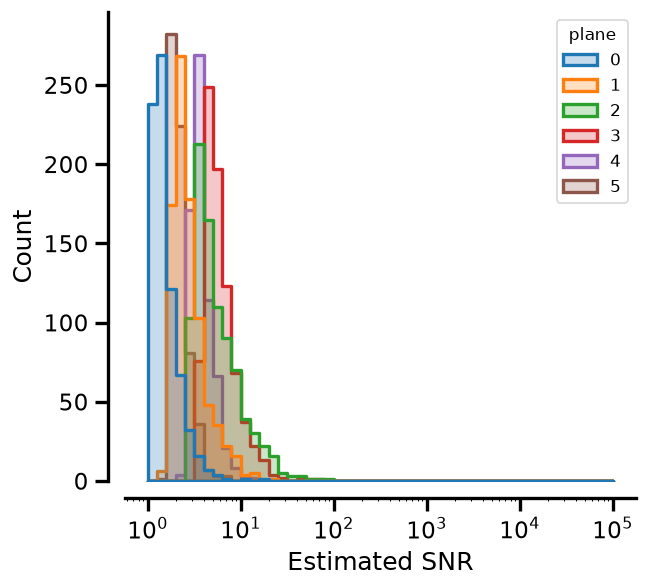

In [34]:
# Figure 4: Sanity check SNR across different planes (depths) 
# note: concatenates across sessions
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=120)

sns.histplot(data=snr_df, x="snr", hue="plane", palette="tab10",
             bins=np.logspace(0, 5, 51), element="step", lw=2, ax=ax)

ax.set_xscale("log")
ax.tick_params(axis="both", which="major", labelsize=14, width=2, length=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.set_xlabel("Estimated SNR", fontsize=15)
ax.set_ylabel("Count", fontsize=15)

sns.despine(offset=10, trim=False)
plt.tight_layout()
plt.show()

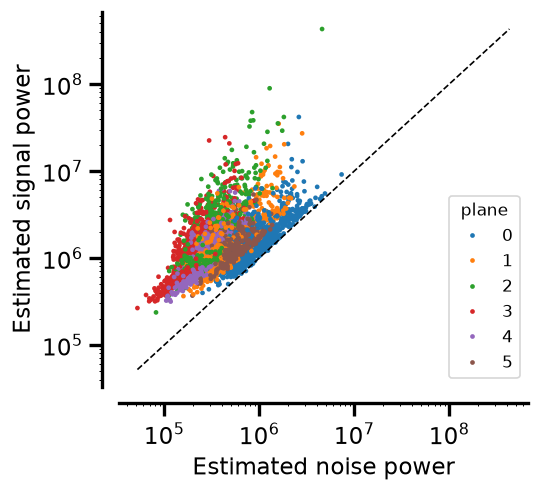

In [35]:
# Figure 5: Sanity check signal power vs noise power across different planes (depths) 
# note: concatenates across sessions
fig, ax = plt.subplots(figsize=(4.6, 4.2), dpi=120)

sns.scatterplot(data=snr_df, x="noise_power", y="signal_power", hue="plane",
                palette="tab10", s=8, linewidth=0, ax=ax)

# unity line from the data limits 
lo = float(min(snr_df["noise_power"].min(), snr_df["signal_power"].min()))
hi = float(max(snr_df["noise_power"].max(), snr_df["signal_power"].max()))
ax.plot((lo, hi), (lo, hi), ls="--", c="k", lw=1)

ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", which="major", labelsize=14, width=2, length=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.set_xlabel("Estimated noise power", fontsize=14)
ax.set_ylabel("Estimated signal power", fontsize=14)

sns.despine(offset=10, trim=False)
plt.tight_layout()
plt.show()

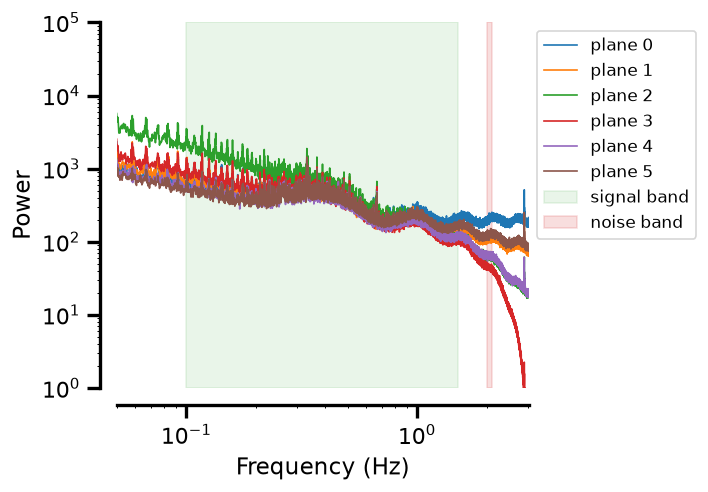

In [36]:
# Figure 6: Sanity check frequency power bands across different planes (depths) within the same session

fig, ax = plt.subplots(figsize=(6, 4.2), dpi=120)

for plane in np.unique(session_data["plane"]):
    m = session_data["plane"] == plane
    ax.plot(freqs, power_spectrum[m].mean(axis=0), lw=1, label=f"plane {plane}")

ax.axvspan(0.1, 1.5, color="tab:green", alpha=0.10, zorder=0, label="signal band")
ax.axvspan(2.0, 2.1, color="tab:red", alpha=0.15, zorder=0, label="noise band")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, fs / 2)
ax.set_ylim(1, 1e5)
ax.tick_params(axis="both", which="major", labelsize=13, width=2, length=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.set_xlabel("Frequency (Hz)", fontsize=14)
ax.set_ylabel("Power", fontsize=14)
ax.legend(fontsize=8)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine(offset=10, trim=False)
plt.tight_layout()
plt.show()

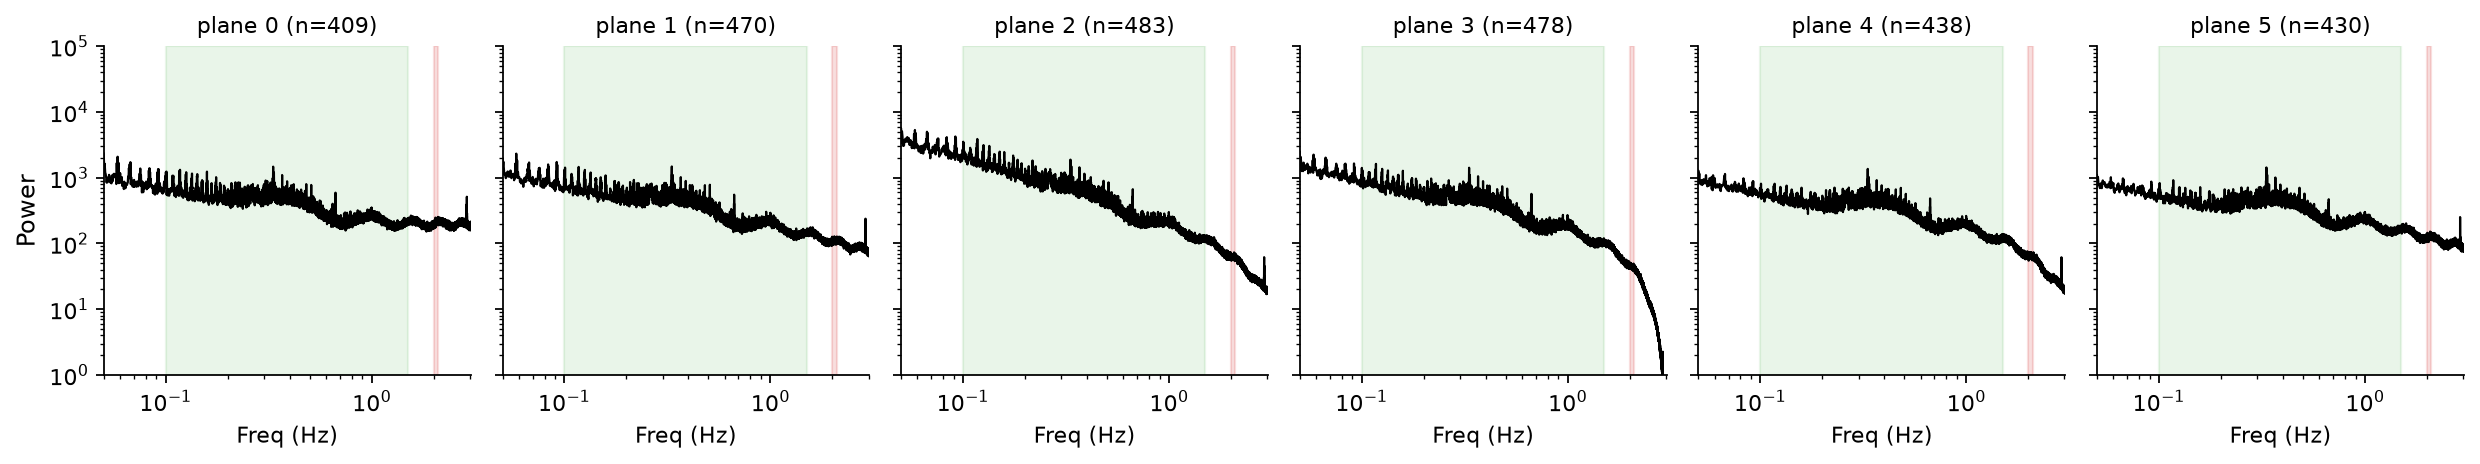

In [37]:
# Figure 7: Sanity check frequency power bands, split plots by planes (depth) within the same session

planes = np.unique(session_data["plane"])
fig, axes = plt.subplots(1, len(planes), figsize=(2.6 * len(planes), 3.0), dpi=160,
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, plane in zip(axes, planes):
    m = session_data["plane"] == plane
    ax.plot(freqs, power_spectrum[m].mean(axis=0), lw=1, color="k")
    ax.axvspan(0.1, 1.5, color="tab:green", alpha=0.10, zorder=0)
    ax.axvspan(2.0, 2.1, color="tab:red", alpha=0.15, zorder=0)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.05, fs / 2)
    ax.set_ylim(1, 1e5)
    ax.set_title(f"plane {plane} (n={int(m.sum())})", fontsize=10)
    ax.set_xlabel("Freq (Hz)", fontsize=10)

axes[0].set_ylabel("Power", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

## Follow-up topic ideas:

* Run the correlation with deconvolved events instead of fluorescence (dff). Will increase the SNR of activity, but may lose the analog nuance of dff traces.
* Run correlation during behavior epochs (like derived from a behavioral state analysis) independent of the visual stimulus.